## VTMM3 — Görüntü başına **tek** rastgele 448×448 kırpma, uzun epoch

**VTMM2’den fark:** Dört sabit dörtlük veya dört ayrı seçim yok. Her `__getitem__`’te tam görüntüden (gerekirse ölçeklendikten sonra) **yalnızca bir adet rastgele 448×448 pencere** kesilir — yani hâlâ **random**, ama **tek** görünüm. Eğitimde augment devam eder; test tarafında da her yüklemede bu tek rastgele kırpma kullanılır (metrik biraz gürültülü olabilir, isterseniz sonra testi merkez kırpmaya sabitleyebilirsiniz).

- Çıktılar: **`vtmm3/`**
- **CAPS:** VTMM2 ile uyumlu donma-çözme ve düzenlileştirme.

Yolları kendi ortamınıza göre güncelleyin.


In [1]:
# --- LIBRARIES ---
import os
import random

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import re
from PIL import Image
from IPython.display import display

from framework import WheatFramework, generate_group_folds, save_model, run_fold_with_trainer


In [2]:
# Update paths if different on your machine
excel_path = r".\labeling.xlsx"
data_path = r".\data"


Searching for images in: c:\Users\PC\Desktop\AI_TARBIL\code\data
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_01-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-01
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_02-10_10-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-02
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_03-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-03
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_05-10_11-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-05
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_06-10_12-K1-1X.jpeg (matched date in filename) -   Parsed date 1: 2014-01-06
Found image: c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\2014\K1\1X\02_02-2014_01_07-09_53-K1-1X.jpeg (matched date in filename)

,path,label
0,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
1,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
2,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
3,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
4,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
5,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
6,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0
7,c:\Users\PC\Desktop\AI_TARBIL\code\data\02.02\...,PS0


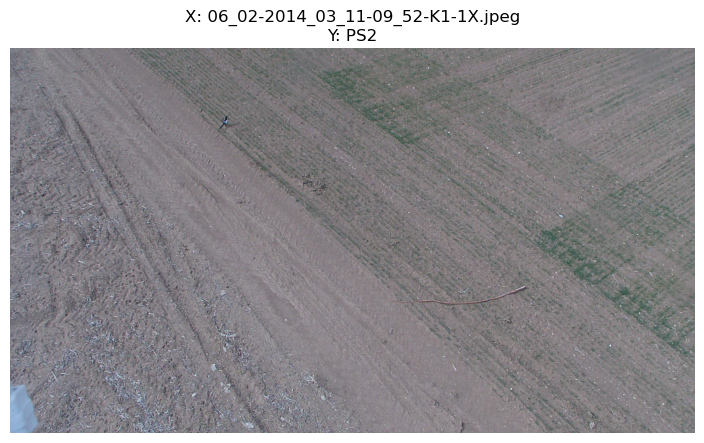

In [3]:
wf = WheatFramework(excel_path=excel_path, root_dir=data_path)

try:
    meta_df = wf.get_dataframe()
except Exception as e:
    print("Error loading data:", e)
    meta_df = pd.DataFrame()

if not meta_df.empty:
    X, y, folds = wf.get_splits(meta_df, n_splits=5)
    print(f"Total matched images: {len(X)}")

    classes = list(wf.le.classes_)
    mapping = {i: cls for i, cls in enumerate(classes)}
    print("\nLabel mapping (encoded -> label):")
    for k, v in mapping.items():
        print(k, ":", v)

    print("\nSample matched paths and labels:")
    display(meta_df[["path", "label"]].head(8))

    wf.get_sample(X, y)
else:
    print("No images matched. Review previous prints above for column mapping and search path.")


In [4]:
# --- VTMM3: DUAL ViT — ONE RANDOM 448 CROP PER IMAGE (no 4-tile), LONG EPOCHS ---

TURKEY_COORDS = {
    1: (37.00, 35.32), 2: (37.76, 38.27), 3: (38.75, 30.55), 4: (39.71, 43.05), 5: (40.65, 35.83),
    6: (39.93, 32.85), 7: (36.89, 30.71), 8: (41.18, 41.81), 9: (37.84, 27.84), 10: (39.64, 27.88),
    11: (40.14, 29.97), 12: (38.88, 40.49), 13: (38.39, 42.10), 14: (40.73, 31.60), 15: (37.71, 30.28),
    16: (40.18, 29.06), 17: (40.15, 26.40), 18: (40.60, 33.61), 19: (40.54, 34.95), 20: (37.77, 29.08),
    21: (37.91, 40.23), 22: (41.67, 26.55), 23: (38.68, 39.22), 24: (39.74, 39.49), 25: (39.90, 41.27),
    26: (39.77, 30.52), 27: (37.06, 37.38), 28: (40.91, 38.38), 29: (40.45, 39.48), 30: (37.57, 43.73),
    31: (36.20, 36.15), 32: (37.76, 30.55), 33: (36.81, 34.64), 34: (41.00, 28.97), 35: (38.41, 27.14),
    36: (40.60, 43.09), 37: (41.37, 33.77), 38: (38.73, 35.48), 39: (41.73, 27.22), 40: (39.14, 34.16),
    41: (40.85, 29.88), 42: (37.87, 32.48), 43: (39.41, 29.98), 44: (38.35, 38.33), 45: (38.61, 27.42),
    46: (37.57, 36.92), 47: (37.31, 40.73), 48: (37.21, 28.36), 49: (38.73, 41.49), 50: (38.62, 34.71),
    51: (37.96, 34.67), 52: (40.98, 37.87), 53: (41.02, 40.51), 54: (40.77, 30.39), 55: (41.28, 36.33),
    56: (37.92, 41.94), 57: (42.02, 35.15), 58: (39.74, 37.01), 59: (40.97, 27.51), 60: (40.32, 36.55),
    61: (41.00, 39.71), 62: (39.10, 39.54), 63: (37.16, 38.79), 64: (38.67, 29.40), 65: (38.50, 43.37),
    66: (39.82, 34.80), 67: (41.45, 31.78), 68: (38.36, 34.02), 69: (40.26, 40.22), 70: (37.18, 33.21),
    71: (39.84, 33.51), 72: (37.88, 41.12), 73: (37.51, 42.45), 74: (41.63, 32.33), 75: (41.11, 42.70),
    76: (39.92, 44.04), 77: (40.65, 29.27), 78: (41.19, 32.62), 79: (36.71, 37.11), 80: (37.07, 36.24),
    81: (40.84, 31.15),
}
DEFAULT_COORD = (39.93, 32.85)


def prepare_advanced_features(df):
    df = df.copy()

    def extract_date(path):
        match = re.search(r"(\d{4}[_-]\d{2}[_-]\d{2})", str(path))
        if not match:
            return pd.NaT
        return pd.to_datetime(match.group(1).replace("-", "_"), format="%Y_%m_%d", errors="coerce")

    df["dt"] = df["path"].apply(extract_date)

    def get_agricultural_doy(date):
        if pd.isna(date):
            return np.nan
        planting_year = date.year if date.month >= 11 else date.year - 1
        nov_1st = pd.Timestamp(year=planting_year, month=11, day=1)
        return (date - nov_1st).days + 1

    df["agri_day_of_year"] = df["dt"].apply(get_agricultural_doy)
    df["date_missing"] = df["dt"].isna().astype(np.float32)
    df["plate_code"] = df["station_year"].astype(str).str.extract(r"^(\d{2})")[0].astype(float)

    def get_lat_lon(plate):
        if pd.isna(plate) or int(plate) not in TURKEY_COORDS:
            return DEFAULT_COORD
        return TURKEY_COORDS[int(plate)]

    coords = df["plate_code"].apply(get_lat_lon)
    df["latitude"] = [c[0] for c in coords]
    df["longitude"] = [c[1] for c in coords]
    return df


def _ensure_min_side(img: Image.Image, min_side: int) -> Image.Image:
    w, h = img.size
    if min(w, h) >= min_side:
        return img
    scale = min_side / min(w, h)
    nw, nh = max(int(round(w * scale)), min_side), max(int(round(h * scale)), min_side)
    return img.resize((nw, nh), Image.BICUBIC)


def _random_square_crop_pil(img: Image.Image, crop_size: int) -> Image.Image:
    img = _ensure_min_side(img, crop_size)
    w, h = img.size
    left = random.randint(0, w - crop_size)
    top = random.randint(0, h - crop_size)
    return img.crop((left, top, left + crop_size, top + crop_size))


class MultimodalSingleCropDataset(Dataset):
    # One random 448×448 crop per sample (not four quadrants / four draws).

    def __init__(self, df, label_map, crop_size, train_transform, eval_transform, is_training=True):
        self.df = df.reset_index(drop=True)
        self.label_map = label_map
        self.crop_size = int(crop_size)
        self.train_transform = train_transform
        self.eval_transform = eval_transform
        self.is_training = is_training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        patch = _random_square_crop_pil(img, self.crop_size)

        if self.is_training:
            if self.train_transform:
                patch = self.train_transform(patch)
        else:
            if self.eval_transform:
                patch = self.eval_transform(patch)
        img_data = patch

        agri_day = row["agri_day_of_year"]
        lat_norm = row["latitude"]
        lon_norm = row["longitude"]
        meta_tensor = torch.tensor([agri_day, lat_norm, lon_norm], dtype=torch.float32)
        label_tensor = torch.tensor(self.label_map[row["label"]], dtype=torch.long)
        return img_data, meta_tensor, label_tensor


class MultimodalViTDual(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        from torchvision.models.vision_transformer import interpolate_embeddings

        weights = models.ViT_B_16_Weights.DEFAULT
        vit_num = 2
        self.vit_arr = nn.ModuleList([models.vit_b_16(weights=None, image_size=448) for _ in range(vit_num)])
        state_dict = weights.get_state_dict(progress=True)
        state_dict = interpolate_embeddings(
            image_size=448, patch_size=16, model_state=state_dict, reset_heads=True
        )
        vit_dim = self.vit_arr[0].heads.head.in_features
        for vit in self.vit_arr:
            vit.load_state_dict(state_dict, strict=False)
            vit.heads = nn.Identity()
        self.meta_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(64, 128),
            nn.GELU(),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.38),
            nn.Linear(vit_num * vit_dim + 128, 256),
            nn.GELU(),
            nn.Dropout(0.28),
            nn.Linear(256, 256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, img, meta):
        v_features = torch.cat([vit(img) for vit in self.vit_arr], dim=1)
        m_features = self.meta_net(meta)
        combined = torch.cat((v_features, m_features), dim=1)
        return self.classifier(combined)


def _dual_vit_backbone_params(model):
    ps = []
    for vit in model.vit_arr:
        ps += list(vit.parameters())
    return ps


def _dual_vit_head_params(model):
    return list(model.meta_net.parameters()) + list(model.classifier.parameters())


VTMM3_OUT = "vtmm3"
os.makedirs(VTMM3_OUT, exist_ok=True)


def multimodal_single_crop_trainer(train_df, test_df, fold_id, config):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img_size = config.get("img_size", 448)
    freeze_epochs = int(config.get("freeze_epochs", 2))
    base_lr = config["lr"]
    weight_decay = config.get("weight_decay", 0.08)
    label_smoothing = config.get("label_smoothing", 0.08)
    max_grad_norm = float(config.get("max_grad_norm", 1.0))
    unfreeze_lr_mult = float(config.get("unfreeze_lr_mult", 0.5))
    heads_lr_boost = float(config.get("heads_lr_boost", 2.0))

    all_labels = sorted(train_df["label"].unique())
    label_map = {label: i for i, label in enumerate(all_labels)}
    inv_map = {v: k for k, v in label_map.items()}
    num_classes = len(all_labels)

    for df_ in [train_df, test_df]:
        df_["latitude"] = df_["latitude"].fillna(39.93)
        df_["longitude"] = df_["longitude"].fillna(32.85)
        df_["latitude"] = (df_["latitude"] - 36.20) / (41.73 - 36.20)
        df_["longitude"] = (df_["longitude"] - 26.39) / (43.73 - 26.39)

    train_transform = transforms.Compose(
        [
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply(
                [transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.04)], p=0.55
            ),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.35))], p=0.12),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    eval_transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    train_ds = MultimodalSingleCropDataset(
        train_df, label_map, img_size, train_transform, eval_transform, is_training=True
    )
    test_ds = MultimodalSingleCropDataset(
        test_df, label_map, img_size, train_transform, eval_transform, is_training=False
    )

    bs = config["batch_size"]
    train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=bs, shuffle=False)

    model = MultimodalViTDual(num_classes).to(device)

    for p in _dual_vit_backbone_params(model):
        p.requires_grad = False

    backbone = _dual_vit_backbone_params(model)
    heads = _dual_vit_head_params(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    epochs = config["epochs"]

    eta_min_head = base_lr * heads_lr_boost * 0.05
    if freeze_epochs <= 0:
        for p in backbone:
            p.requires_grad = True
        lr_full = base_lr * unfreeze_lr_mult
        optimizer = optim.AdamW(model.parameters(), lr=lr_full, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, epochs), eta_min=max(lr_full * 0.02, base_lr * 1e-4)
        )
    else:
        optimizer = optim.AdamW(heads, lr=base_lr * heads_lr_boost, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=max(1, freeze_epochs), eta_min=eta_min_head
        )

    best_acc = 0.0
    best_pred_df = None
    best_model_state = None
    acc_not_increased_epoch_num = 0

    print(f"\n{'='*40}")
    print(f"[VTMM3 DUAL ViT] FOLD {fold_id} · one random {img_size}px crop per image (no 4-tile)")
    print(f"{'='*40}")

    for epoch in range(epochs):
        if freeze_epochs > 0 and epoch == freeze_epochs:
            lr_full = base_lr * unfreeze_lr_mult
            print(f"CAPS FREEZE PHASE END epoch={epoch}: UNFREEZE ViT, NEW OPTIM LR={lr_full}")
            for p in backbone:
                p.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=lr_full, weight_decay=weight_decay)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=max(1, epochs - freeze_epochs),
                eta_min=max(lr_full * 0.02, base_lr * 1e-4),
            )

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for imgs, metas, lbls in train_loader:
            metas = metas.to(device)
            lbls = lbls.to(device)
            imgs = imgs.to(device)
            optimizer.zero_grad()
            outputs = model(imgs, metas)
            loss = criterion(outputs, lbls)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += lbls.size(0)
            correct += predicted.eq(lbls).sum().item()

        scheduler.step()

        model.eval()
        all_preds, all_trues = [], []
        with torch.no_grad():
            for imgs, metas, lbls in test_loader:
                imgs = imgs.to(device)
                metas = metas.to(device)
                lbls = lbls.to(device)
                out = model(imgs, metas)
                _, pred = out.max(1)
                all_preds.extend(pred.cpu().tolist())
                all_trues.extend(lbls.cpu().tolist())

        fold_acc = float(np.mean(np.array(all_preds) == np.array(all_trues)))

        print(
            f"[VTMM3 dual] Epoch {epoch+1} train Loss: {running_loss / max(len(train_loader), 1):.4f} "
            f"| train Acc: {100.0 * correct / max(total, 1):.2f}% | test Acc: {fold_acc:.4f}"
        )

        import matplotlib.pyplot as plt
        import seaborn as sns

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            pd.crosstab(pd.Series(all_trues, name="True"), pd.Series(all_preds, name="Pred")),
            annot=True,
            fmt="d",
            cmap="Blues",
        )
        plt.title(f"[VTMM3 dual] Fold {fold_id} epoch {epoch+1}")
        plt.tight_layout()
        plt.savefig(os.path.join(VTMM3_OUT, f"fold_{fold_id}_dual_epoch_{epoch+1}_confusion_matrix.png"))
        plt.close()

        if fold_acc <= best_acc:
            acc_not_increased_epoch_num += 1
        else:
            acc_not_increased_epoch_num = 0
            best_acc = fold_acc
            print(f"  New best test acc {best_acc:.4f}")
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_pred_df = pd.DataFrame(
                {
                    "path": test_df["path"].values,
                    "true": [inv_map[t] for t in all_trues],
                    "pred": [inv_map[p] for p in all_preds],
                }
            )

            model.load_state_dict(best_model_state)
            if best_acc >= float(config.get("save_acc_threshold", 0.70)):
                save_path = os.path.join(VTMM3_OUT, f"fold_{fold_id}_dual_acc{best_acc:.4f}.pth")
                save_model(model, save_path)
                print(f"  CAPS SAVED MODEL (TEST ACC >= threshold): {save_path}")
            model.train()

        if acc_not_increased_epoch_num > 0:
            print(f"  No test improvement for {acc_not_increased_epoch_num} epoch(s)")
        else:
            print("  Accuracy improved — reset patience")

        pat = config.get("patience", 3)
        if acc_not_increased_epoch_num >= pat:
            print(f"CAPS EARLY STOP: no gain {pat} epochs.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"[VTMM3 dual] FOLD {fold_id} BEST TEST ACCURACY: {best_acc:.4f}\n")
    return {"model": model, "predictions": best_pred_df, "metrics": {"accuracy": best_acc}}


multi_config = {
    "img_size": 448,
    "batch_size": 4,
    "lr": 1e-5,
    "epochs": 60,
    "weight_decay": 0.085,
    "label_smoothing": 0.08,
    "max_grad_norm": 1.0,
    "freeze_epochs": 2,
    "unfreeze_lr_mult": 0.45,
    "heads_lr_boost": 2.0,
    "save_acc_threshold": 0.70,
    "patience": 12,
}

meta_df_advanced = prepare_advanced_features(meta_df)

folds = generate_group_folds(
    meta_df_advanced, n_train=8, n_test=2, num_folds=5, group_col="group_id", random_state=42
)
multi_metrics = []

for f_idx, (tr_idx, te_idx) in enumerate(folds):
    result = run_fold_with_trainer(
        meta_df=meta_df_advanced,
        train_idx=tr_idx,
        test_idx=te_idx,
        trainer_fn=lambda tr, te, fid: multimodal_single_crop_trainer(tr, te, fid, multi_config),
        fold_id=f_idx + 1,
    )
    multi_metrics.append(result["metrics"]["accuracy"])

print("\n--- VTMM3 DUAL FINAL MEAN ACC ---")
print(np.mean(multi_metrics))



c:\Users\PC\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1355: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:35.)
  return t.to(



[VTMM3 DUAL ViT] FOLD 1 · one random 448px crop per image (no 4-tile)
[VTMM3 dual] Epoch 1 train Loss: 2.0645 | train Acc: 19.32% | test Acc: 0.1365
  New best test acc 0.1365
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 2 train Loss: 1.9194 | train Acc: 31.23% | test Acc: 0.2152
  New best test acc 0.2152
  Accuracy improved — reset patience
CAPS FREEZE PHASE END epoch=2: UNFREEZE ViT, NEW OPTIM LR=4.5e-06
[VTMM3 dual] Epoch 3 train Loss: 1.7230 | train Acc: 40.12% | test Acc: 0.4357
  New best test acc 0.4357
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 4 train Loss: 1.5208 | train Acc: 51.29% | test Acc: 0.4856
  New best test acc 0.4856
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 5 train Loss: 1.3425 | train Acc: 58.93% | test Acc: 0.4462
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 6 train Loss: 1.2161 | train Acc: 65.69% | test Acc: 0.4934
  New best test acc 0.4934
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 7 train Loss:

KeyboardInterrupt: 

c:\Users\PC\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1355: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:35.)
  return t.to(

========================================
[VTMM3 DUAL ViT] FOLD 1 · train=random 448px crop · test=4-tile avg
========================================
[VTMM3 dual] Epoch 1 train Loss: 2.0118 | train Acc: 21.31% | test Acc: 0.1575
  New best test acc 0.1575
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 2 train Loss: 1.9172 | train Acc: 31.23% | test Acc: 0.1995
  New best test acc 0.1995
  Accuracy improved — reset patience
CAPS FREEZE PHASE END epoch=2: UNFREEZE ViT, NEW OPTIM LR=4.5e-06
[VTMM3 dual] Epoch 3 train Loss: 1.6985 | train Acc: 43.72% | test Acc: 0.4803
  New best test acc 0.4803
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 4 train Loss: 1.4454 | train Acc: 54.22% | test Acc: 0.4934
  New best test acc 0.4934
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 5 train Loss: 1.3096 | train Acc: 61.20% | test Acc: 0.5092
  New best test acc 0.5092
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 6 train Loss: 1.2081 | train Acc: 65.76% | test Acc: 0.5564
  New best test acc 0.5564
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 7 train Loss: 1.1148 | train Acc: 69.07% | test Acc: 0.6194
  New best test acc 0.6194
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 8 train Loss: 1.0371 | train Acc: 73.03% | test Acc: 0.5092
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 9 train Loss: 1.0310 | train Acc: 70.76% | test Acc: 0.5643
  No test improvement for 2 epoch(s)
[VTMM3 dual] Epoch 10 train Loss: 0.9696 | train Acc: 75.97% | test Acc: 0.5958
  No test improvement for 3 epoch(s)
CAPS EARLY STOP: no gain 3 epochs.
[VTMM3 dual] FOLD 1 BEST TEST ACCURACY: 0.6194


========================================
[VTMM3 DUAL ViT] FOLD 2 · train=random 448px crop · test=4-tile avg
========================================
[VTMM3 dual] Epoch 1 train Loss: 2.1000 | train Acc: 20.00% | test Acc: 0.2486
  New best test acc 0.2486
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 2 train Loss: 1.9927 | train Acc: 28.48% | test Acc: 0.3702
  New best test acc 0.3702
  Accuracy improved — reset patience
CAPS FREEZE PHASE END epoch=2: UNFREEZE ViT, NEW OPTIM LR=4.5e-06
[VTMM3 dual] Epoch 3 train Loss: 1.7714 | train Acc: 39.13% | test Acc: 0.4751
  New best test acc 0.4751
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 4 train Loss: 1.5284 | train Acc: 50.94% | test Acc: 0.4945
  New best test acc 0.4945
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 5 train Loss: 1.3572 | train Acc: 59.57% | test Acc: 0.4641
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 6 train Loss: 1.2352 | train Acc: 65.22% | test Acc: 0.5028
  New best test acc 0.5028
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 7 train Loss: 1.1700 | train Acc: 66.59% | test Acc: 0.5055
  New best test acc 0.5055
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 8 train Loss: 1.0891 | train Acc: 72.75% | test Acc: 0.4972
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 9 train Loss: 1.0197 | train Acc: 74.57% | test Acc: 0.5055
  No test improvement for 2 epoch(s)
[VTMM3 dual] Epoch 10 train Loss: 0.9937 | train Acc: 76.30% | test Acc: 0.5193
  New best test acc 0.5193
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 11 train Loss: 0.9789 | train Acc: 76.52% | test Acc: 0.4972
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 12 train Loss: 0.9787 | train Acc: 75.72% | test Acc: 0.5028
  No test improvement for 2 epoch(s)
[VTMM3 dual] FOLD 2 BEST TEST ACCURACY: 0.5193


========================================
[VTMM3 DUAL ViT] FOLD 3 · train=random 448px crop · test=4-tile avg
========================================
[VTMM3 dual] Epoch 1 train Loss: 2.1590 | train Acc: 20.76% | test Acc: 0.2817
  New best test acc 0.2817
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 2 train Loss: 1.9892 | train Acc: 31.72% | test Acc: 0.3549
  New best test acc 0.3549
  Accuracy improved — reset patience
CAPS FREEZE PHASE END epoch=2: UNFREEZE ViT, NEW OPTIM LR=4.5e-06
[VTMM3 dual] Epoch 3 train Loss: 1.8123 | train Acc: 37.49% | test Acc: 0.4479
  New best test acc 0.4479
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 4 train Loss: 1.6003 | train Acc: 45.42% | test Acc: 0.4648
  New best test acc 0.4648
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 5 train Loss: 1.4497 | train Acc: 53.21% | test Acc: 0.5155
  New best test acc 0.5155
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 6 train Loss: 1.3360 | train Acc: 60.13% | test Acc: 0.6254
  New best test acc 0.6254
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 7 train Loss: 1.2443 | train Acc: 64.60% | test Acc: 0.5944
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 8 train Loss: 1.1581 | train Acc: 68.57% | test Acc: 0.5887
  No test improvement for 2 epoch(s)
[VTMM3 dual] Epoch 9 train Loss: 1.1340 | train Acc: 69.79% | test Acc: 0.6366
  New best test acc 0.6366
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 10 train Loss: 1.0802 | train Acc: 71.52% | test Acc: 0.6282
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 11 train Loss: 1.0780 | train Acc: 72.96% | test Acc: 0.6141
  No test improvement for 2 epoch(s)
[VTMM3 dual] Epoch 12 train Loss: 1.0503 | train Acc: 73.18% | test Acc: 0.6113
  No test improvement for 3 epoch(s)
CAPS EARLY STOP: no gain 3 epochs.
[VTMM3 dual] FOLD 3 BEST TEST ACCURACY: 0.6366


========================================
[VTMM3 DUAL ViT] FOLD 4 · train=random 448px crop · test=4-tile avg
========================================
[VTMM3 dual] Epoch 1 train Loss: 2.1281 | train Acc: 25.82% | test Acc: 0.2798
  New best test acc 0.2798
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 2 train Loss: 2.0021 | train Acc: 32.43% | test Acc: 0.3095
  New best test acc 0.3095
  Accuracy improved — reset patience
CAPS FREEZE PHASE END epoch=2: UNFREEZE ViT, NEW OPTIM LR=4.5e-06
[VTMM3 dual] Epoch 3 train Loss: 1.8322 | train Acc: 37.27% | test Acc: 0.3839
  New best test acc 0.3839
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 4 train Loss: 1.6250 | train Acc: 46.37% | test Acc: 0.4256
  New best test acc 0.4256
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 5 train Loss: 1.4913 | train Acc: 50.28% | test Acc: 0.4851
  New best test acc 0.4851
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 6 train Loss: 1.3505 | train Acc: 56.19% | test Acc: 0.4881
  New best test acc 0.4881
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 7 train Loss: 1.2997 | train Acc: 59.67% | test Acc: 0.5268
  New best test acc 0.5268
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 8 train Loss: 1.2307 | train Acc: 63.87% | test Acc: 0.5417
  New best test acc 0.5417
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 9 train Loss: 1.1694 | train Acc: 66.93% | test Acc: 0.5923
  New best test acc 0.5923
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 10 train Loss: 1.1369 | train Acc: 67.85% | test Acc: 0.6577
  New best test acc 0.6577
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 11 train Loss: 1.1187 | train Acc: 70.13% | test Acc: 0.6399
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 12 train Loss: 1.1137 | train Acc: 69.49% | test Acc: 0.6607
  New best test acc 0.6607
  Accuracy improved — reset patience
[VTMM3 dual] FOLD 4 BEST TEST ACCURACY: 0.6607


========================================
[VTMM3 DUAL ViT] FOLD 5 · train=random 448px crop · test=4-tile avg
========================================
[VTMM3 dual] Epoch 1 train Loss: 2.0808 | train Acc: 22.06% | test Acc: 0.2282
  New best test acc 0.2282
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 2 train Loss: 1.9589 | train Acc: 32.37% | test Acc: 0.2592
  New best test acc 0.2592
  Accuracy improved — reset patience
CAPS FREEZE PHASE END epoch=2: UNFREEZE ViT, NEW OPTIM LR=4.5e-06
[VTMM3 dual] Epoch 3 train Loss: 1.7295 | train Acc: 42.68% | test Acc: 0.4901
  New best test acc 0.4901
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 4 train Loss: 1.5133 | train Acc: 50.61% | test Acc: 0.6197
  New best test acc 0.6197
  Accuracy improved — reset patience
[VTMM3 dual] Epoch 5 train Loss: 1.3544 | train Acc: 57.25% | test Acc: 0.5718
  No test improvement for 1 epoch(s)
[VTMM3 dual] Epoch 6 train Loss: 1.2335 | train Acc: 63.73% | test Acc: 0.5634
  No test improvement for 2 epoch(s)
[VTMM3 dual] Epoch 7 train Loss: 1.1383 | train Acc: 68.64% | test Acc: 0.5690
  No test improvement for 3 epoch(s)
CAPS EARLY STOP: no gain 3 epochs.
[VTMM3 dual] FOLD 5 BEST TEST ACCURACY: 0.6197


--- VTMM3 DUAL FINAL MEAN ACC ---
0.6111623805272727